In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("drug200.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
print(df.info())
print("İsnull values: ")
print(df.isnull().sum())
display(df.head(5))

Shape:  (200, 6)
Columns:  Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None
İsnull values: 
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [3]:
print(df["Drug"].value_counts())

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [4]:
df_clean = df.copy()
df_clean["Drug"] = df_clean["Drug"].str.lower()
print(df_clean["Drug"].value_counts())

Drug
drugy    91
drugx    54
druga    23
drugc    16
drugb    16
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df_clean["Drug"] = label.fit_transform(df_clean["Drug"])
print(df_clean["Drug"].value_counts())

Drug
4    91
3    54
0    23
2    16
1    16
Name: count, dtype: int64


In [6]:
print(df_clean["Sex"].value_counts())
df_clean["Sex"] = np.where(df_clean["Sex"].str.contains("F"),0,1)
print(df_clean["Sex"].value_counts())

Sex
M    104
F     96
Name: count, dtype: int64
Sex
1    104
0     96
Name: count, dtype: int64


In [7]:
print(df_clean["BP"].unique())
print(df_clean["BP"].value_counts())

['HIGH' 'LOW' 'NORMAL']
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64


In [8]:
mapping = {
    "LOW": 0,
    "NORMAL": 1,
    "HIGH": 2
}
df_clean["BP"] = df_clean["BP"].map(mapping)
print(df_clean["BP"].value_counts())

BP
2    77
0    64
1    59
Name: count, dtype: int64


In [9]:
print(df_clean["Cholesterol"].unique())
print(df_clean["Cholesterol"].value_counts())

['HIGH' 'NORMAL']
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


In [10]:
mapping_col = {
    "NORMAL": 0,
    "HIGH": 1
}
df_clean["Cholesterol"] = df_clean["Cholesterol"].map(mapping_col)
print(df_clean["Cholesterol"].value_counts())

Cholesterol
1    103
0     97
Name: count, dtype: int64


In [11]:
print(df_clean.info())
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB
None
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
X = df_clean.drop("Drug", axis=1)
y = df_clean["Drug"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
ovr = OneVsRestClassifier(estimator=LogisticRegression())
ovr.fit(X_train_scaled, y_train)
y_pred = ovr.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred))
print("Classification report: ", "\n", classification_report(y_test, y_pred))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred))

Score:  0.9
Classification report:  
               precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.50      0.67         4
           2       1.00      0.75      0.86         4
           3       0.93      0.87      0.90        15
           4       0.92      1.00      0.96        22

    accuracy                           0.90        50
   macro avg       0.91      0.82      0.84        50
weighted avg       0.91      0.90      0.90        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 2  2  0  0  0]
 [ 0  0  3  1  0]
 [ 0  0  0 13  2]
 [ 0  0  0  0 22]]


In [15]:
penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 10, 1, 0.1, 0.01]
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
params = dict(estimator__penalty=penalty, estimator__C=c_values, estimator__solver=solvers)

In [16]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold()
model = OneVsRestClassifier(estimator=LogisticRegression())
grid = GridSearchCV(estimator=model, cv=cv, param_grid=params, n_jobs=-1, scoring="accuracy")
grid.fit(X_train_scaled, y_train)
y_pred2 = grid.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred2))
print("Classification report: ", "\n", classification_report(y_test, y_pred2))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred2))
print(grid.best_params_)

Score:  0.96
Classification report:  
               precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.50      0.67         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        22

    accuracy                           0.96        50
   macro avg       0.94      0.90      0.90        50
weighted avg       0.97      0.96      0.96        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 2  2  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 22]]
{'estimator__C': 10, 'estimator__penalty': 'l1', 'estimator__solver': 'liblinear'}


In [17]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_scaled, y_train)
y_pred3 = svc.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred3))
print("Classification report: ", "\n", classification_report(y_test, y_pred3))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred3))

Score:  0.96
Classification report:  
               precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      0.95      0.98        22

    accuracy                           0.96        50
   macro avg       0.94      0.94      0.93        50
weighted avg       0.97      0.96      0.96        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 1  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 1  0  0  0 21]]


In [18]:
params = {
    "kernel": ["rbf", "linear", "poly", "sigmoid"],
    "C": [100,10,1,0.1,0.01],
    "gamma": ["auto", "scale"]
}
cv = StratifiedKFold()
grid2 = GridSearchCV(estimator=SVC(), param_grid=params, n_jobs=-1, scoring="accuracy", cv=cv)
grid2.fit(X_train_scaled, y_train)
y_pred4 = grid2.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred4))
print("Classification report: ", "\n", classification_report(y_test, y_pred4))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred4))

Score:  0.98
Classification report:  
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        22

    accuracy                           0.98        50
   macro avg       0.97      0.95      0.95        50
weighted avg       0.98      0.98      0.98        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 1  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 22]]


In [19]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred5 = gnb.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred5))
print("Classification report: ", "\n", classification_report(y_test, y_pred5))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred5))

Score:  0.82
Classification report:  
               precision    recall  f1-score   support

           0       0.56      1.00      0.71         5
           1       1.00      0.75      0.86         4
           2       0.44      1.00      0.62         4
           3       1.00      1.00      1.00        15
           4       1.00      0.64      0.78        22

    accuracy                           0.82        50
   macro avg       0.80      0.88      0.79        50
weighted avg       0.91      0.82      0.83        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 1  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 3  0  5  0 14]]


In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3, weights="uniform", algorithm="auto")
knn.fit(X_train_scaled, y_train)
y_pred6 = knn.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred6))
print("Classification report: ", "\n", classification_report(y_test, y_pred6))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred6))

Score:  0.86
Classification report:  
               precision    recall  f1-score   support

           0       0.56      1.00      0.71         5
           1       1.00      0.50      0.67         4
           2       0.60      0.75      0.67         4
           3       1.00      1.00      1.00        15
           4       0.95      0.82      0.88        22

    accuracy                           0.86        50
   macro avg       0.82      0.81      0.79        50
weighted avg       0.90      0.86      0.86        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 2  2  0  0  0]
 [ 0  0  3  0  1]
 [ 0  0  0 15  0]
 [ 2  0  2  0 18]]


In [21]:
# Names:
# grid - Logistic Regression
# grid2 - Support Vector Classifier
# gnb - Gaussian Naive Bayes
# knn - K nearest neighbours

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve

def roc_auc(model, y_test, X_test):
    classes = model.classes_
    y_test_bin = label_binarize(y_test, classes=classes)
    
    if hasattr(model, "predict_proba"):
        y_skor = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_skor = model.decision_function(X_test)
    else:
        return "Model için ROC hesaplaması yapılamaz!"
        
    n_classes = len(classes)
    fig, ax = plt.subplots(1,n_classes,figsize=(20,10))

    if n_classes == 1:
        ax = [ax]
    
    for i, cls in enumerate(classes):
        y_true_i = y_test_bin[:,i]
        y_skor_i = y_skor[:,i]
        
        if np.unique(y_true_i).size < 2:
            ax[i].set_title(f"Class {i} Testte yok")
            ax[i].set_axis_off()
            continue
            
        fpr, tpr, thresholds = roc_curve(y_true_i, y_skor_i)    
        auc_score = roc_auc_score(y_true_i, y_skor_i)
        ax[i].plot(fpr, tpr, marker=".", label=f"Roc Curve AUC=({auc_score:.2f})")
        ax[i].set_xlabel("False Positive Rate")
        ax[i].set_ylabel("True Positive Rate")
        ax[i].set_title(f"Class {cls} Roc Curve")
        ax[i].legend()

    plt.tight_layout()
    plt.show()

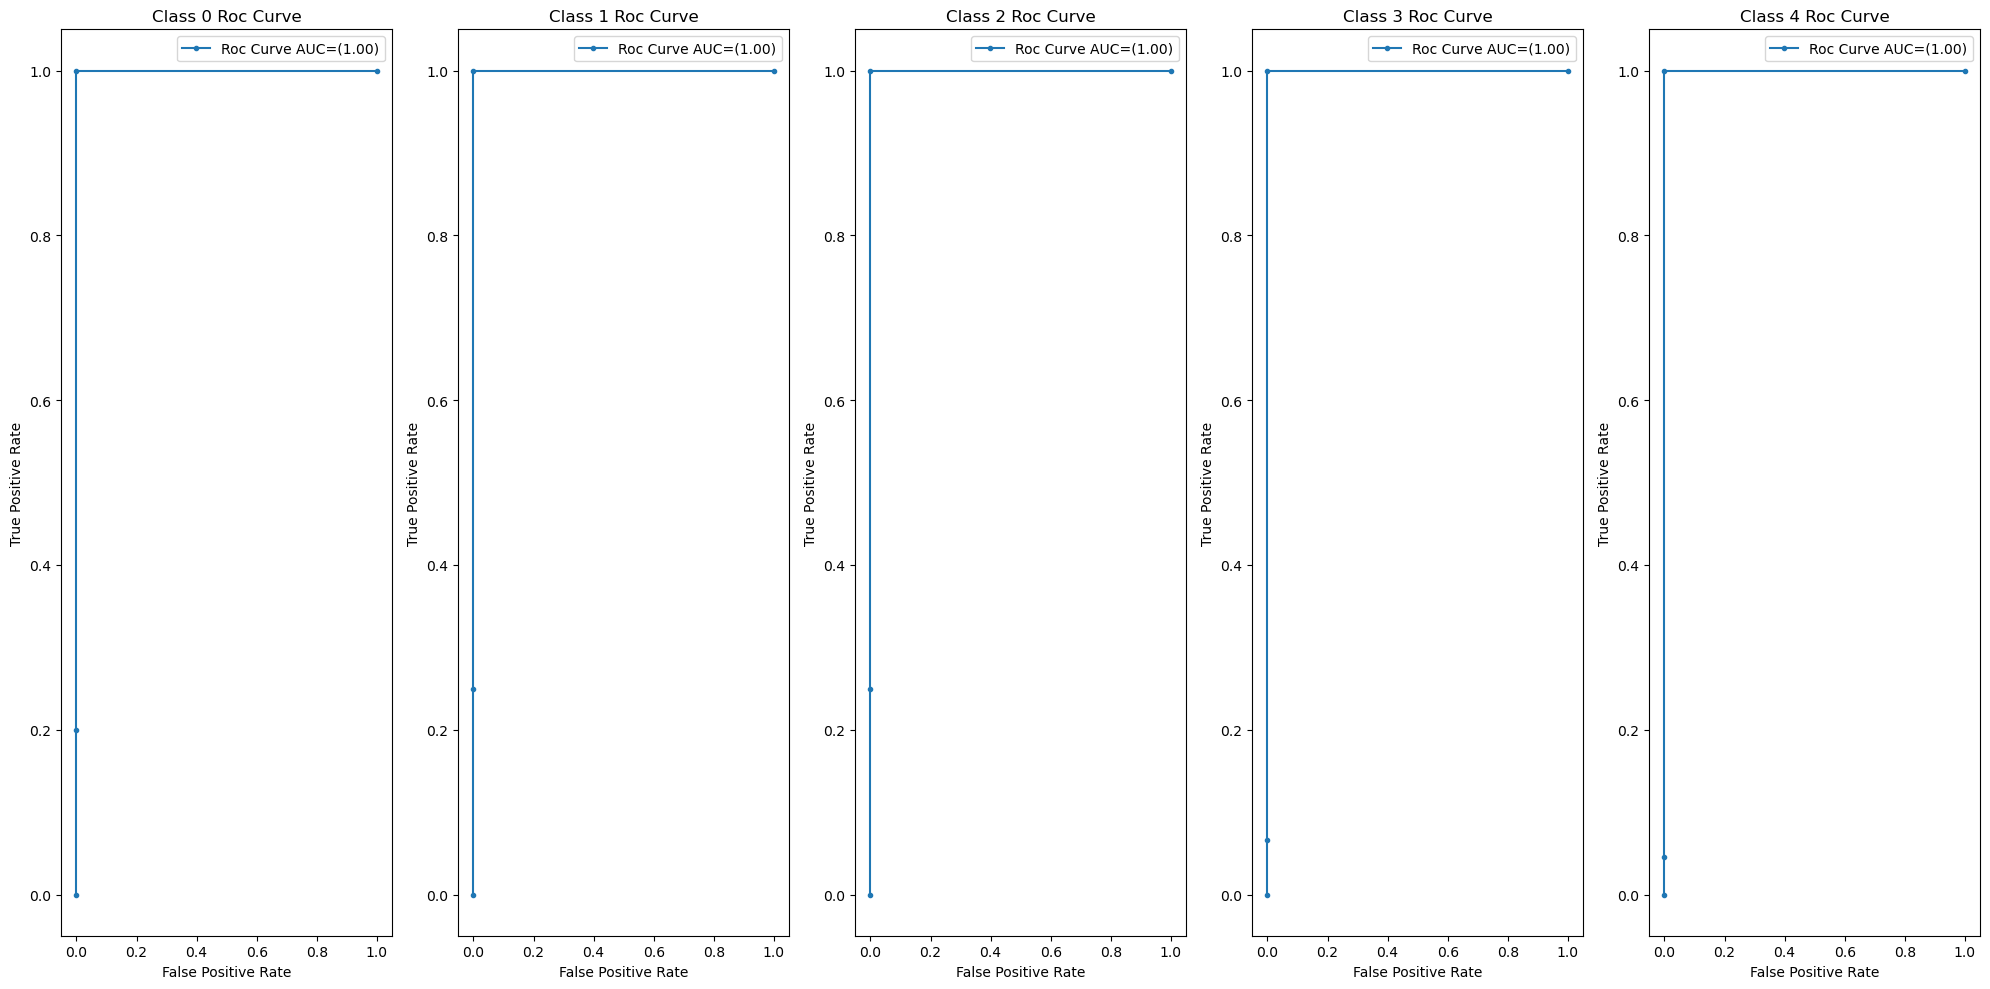

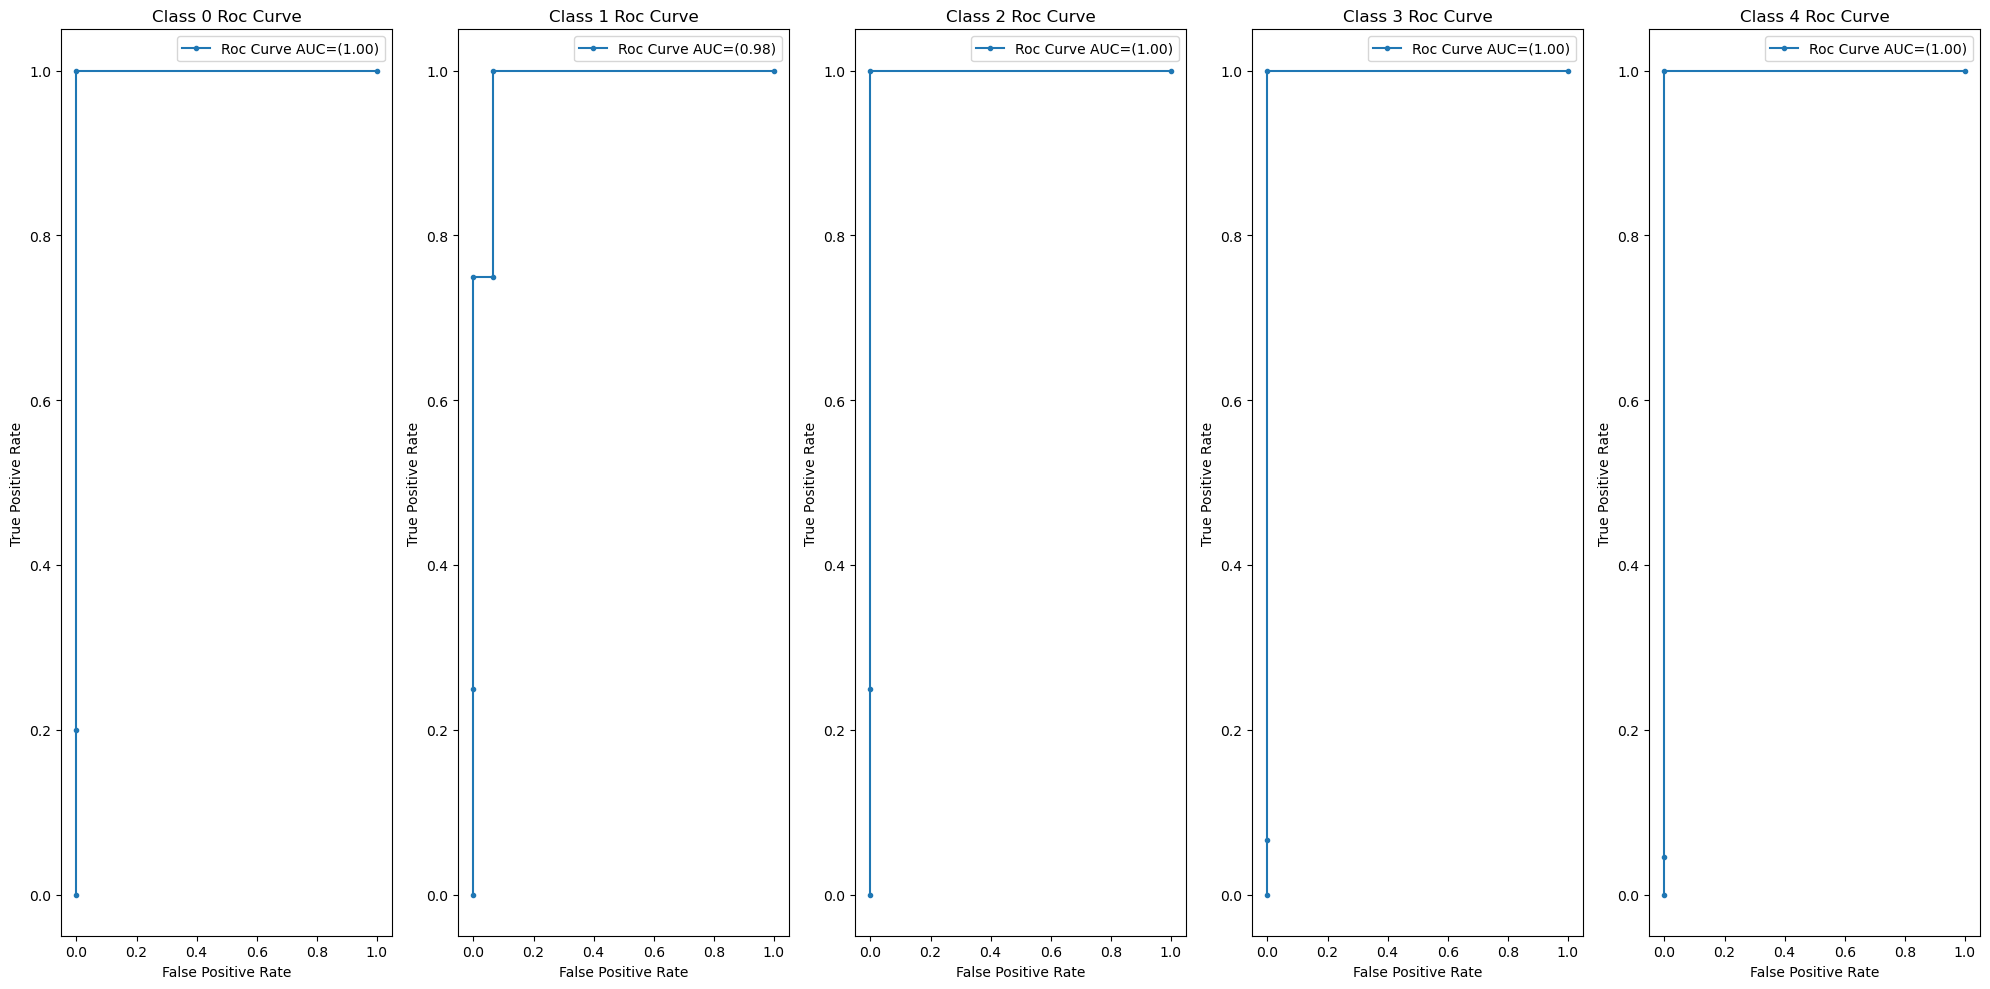

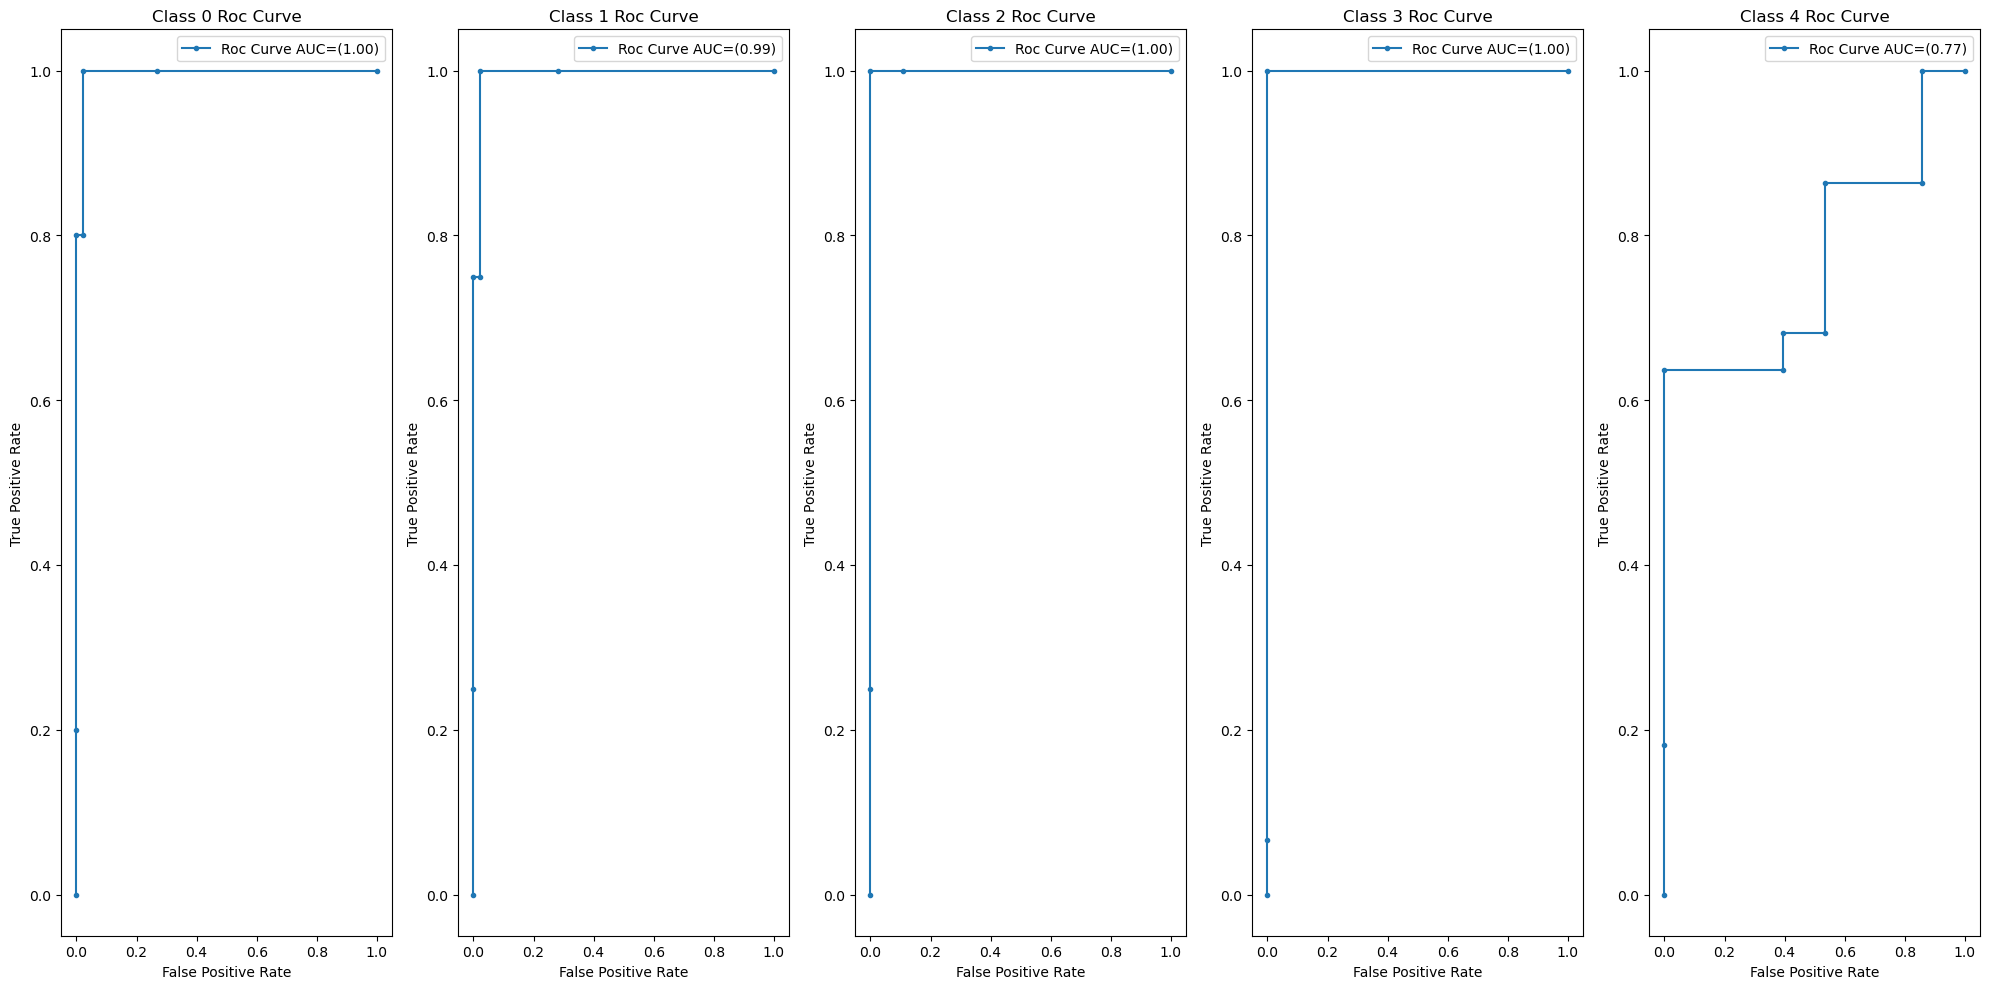

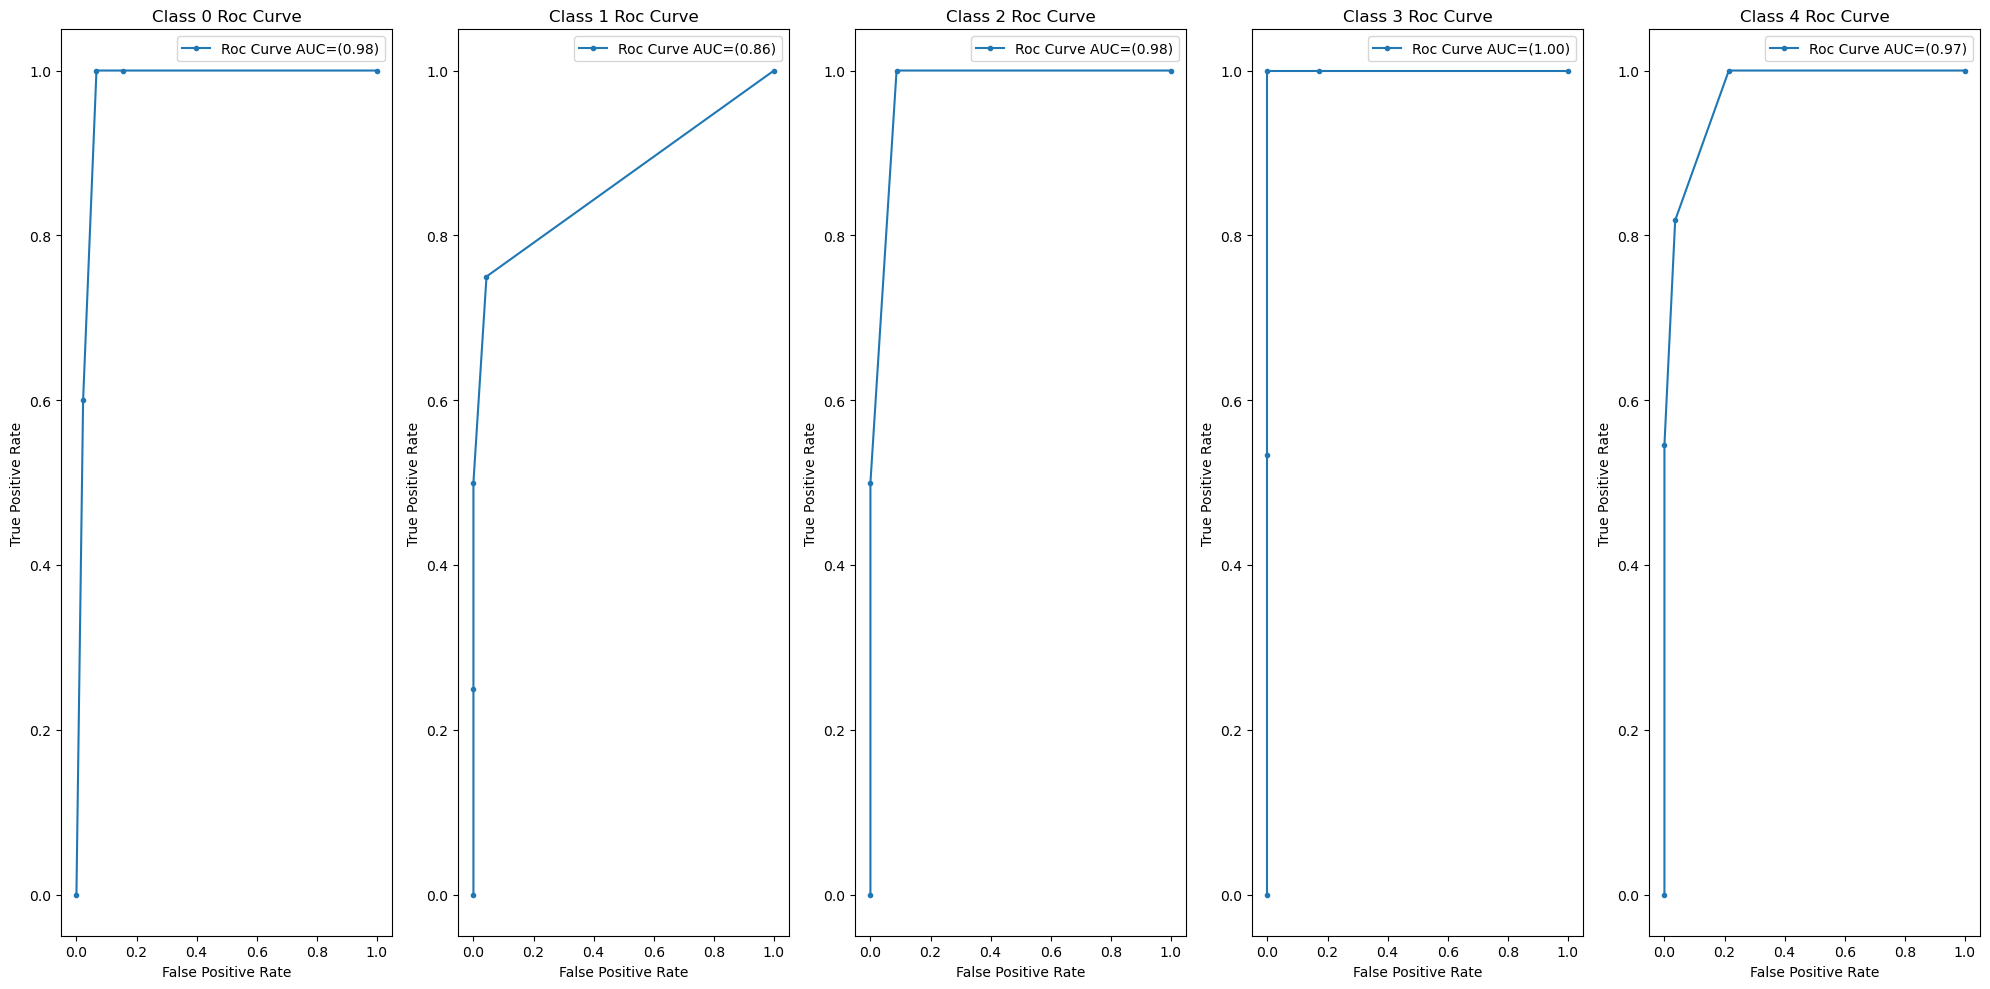

In [23]:
roc_auc(grid, y_test, X_test_scaled)
roc_auc(grid2, y_test, X_test_scaled)
roc_auc(gnb, y_test, X_test_scaled)
roc_auc(knn, y_test, X_test_scaled)

In [24]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train_scaled, y_train)
y_pred7 = tree.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred7))
print("Classification Report: ", "\n", classification_report(y_test, y_pred7))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred7))

Score:  0.98
Classification Report:  
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        22

    accuracy                           0.98        50
   macro avg       0.97      0.95      0.95        50
weighted avg       0.98      0.98      0.98        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 1  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 22]]


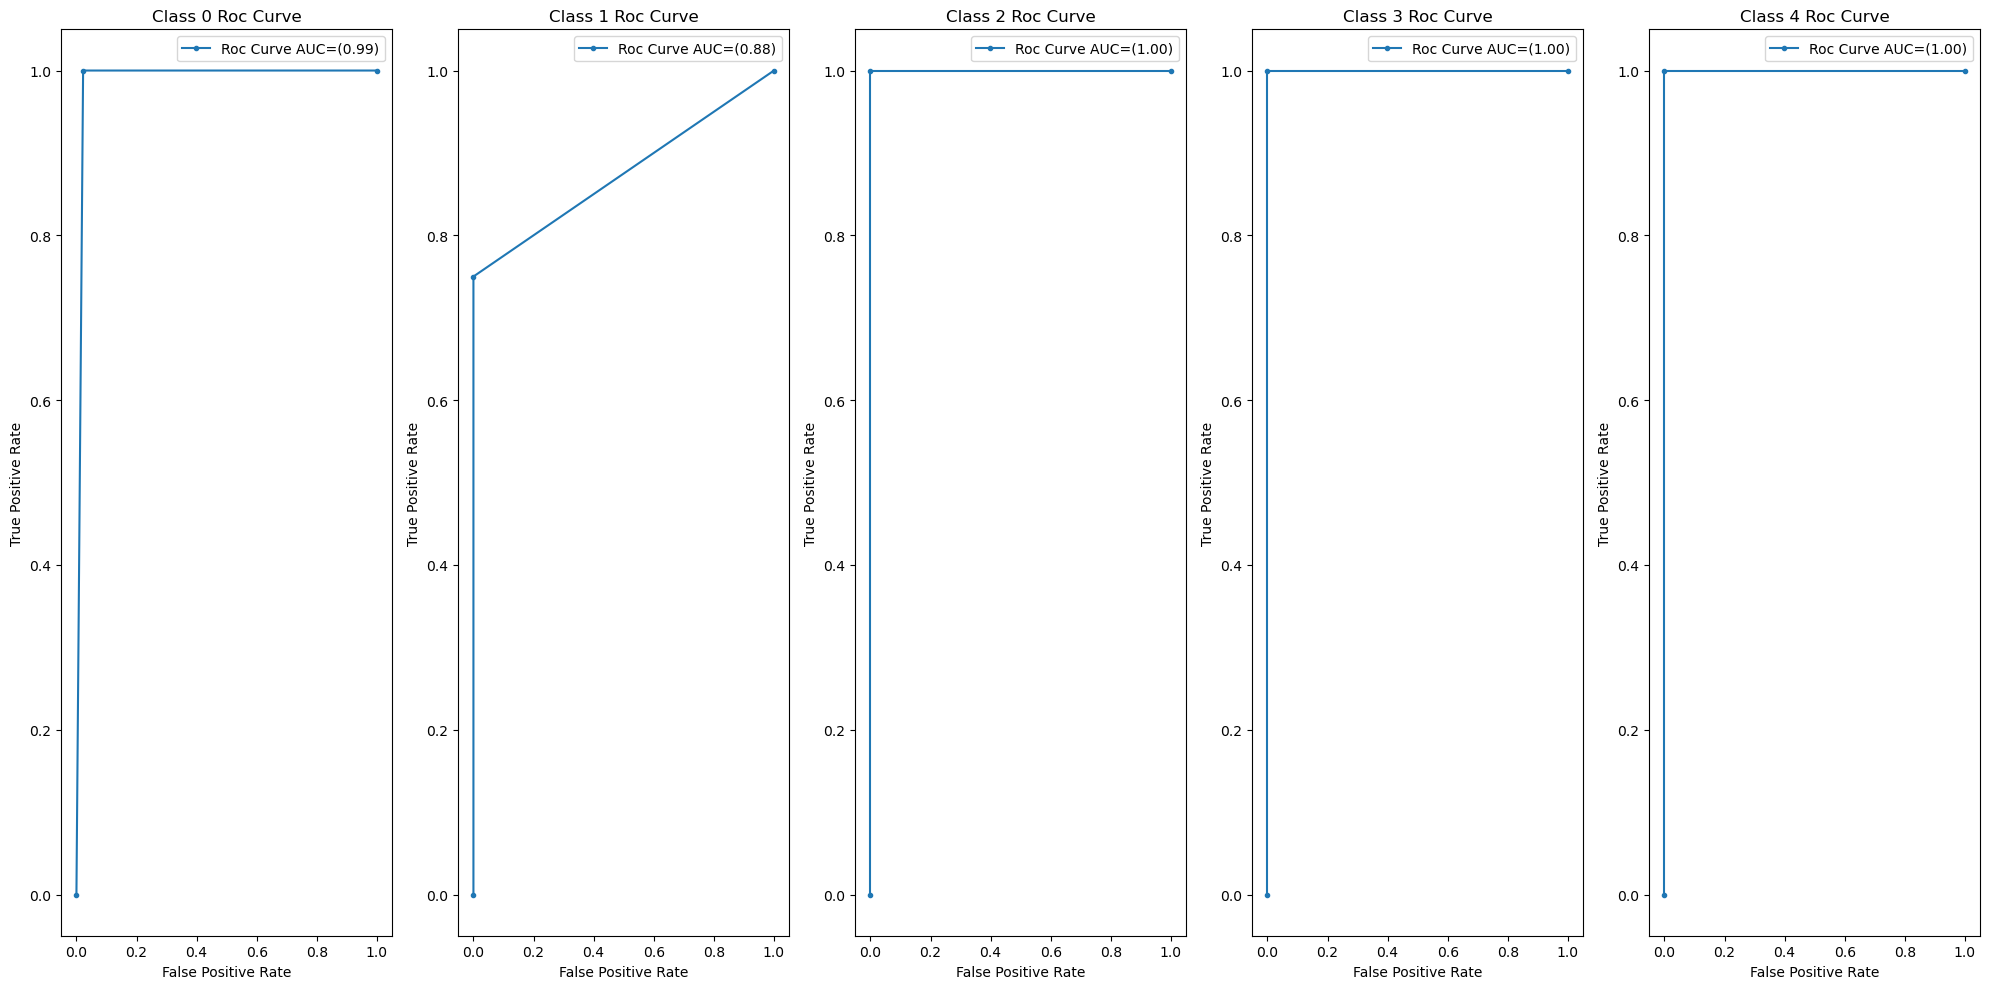

In [41]:
roc_auc(tree, y_test, X_test_scaled)

In [51]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(max_depth=10, max_features="sqrt", min_samples_leaf=1, min_samples_split=2, criterion="gini")
tree1.fit(X_train_scaled, y_train)
y_pred8 = tree.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred8))
print("Classification Report: ", "\n", classification_report(y_test, y_pred8))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred8))

Score:  0.98
Classification Report:  
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        22

    accuracy                           0.98        50
   macro avg       0.97      0.95      0.95        50
weighted avg       0.98      0.98      0.98        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 1  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 22]]


In [49]:
params = {
    "criterion": ["gini", "entropy", "log-loss"],
    "max_depth": [2,5,10,20,50],
    "min_samples_split": [2,5,10,20,50],
    "min_samples_leaf": [1,2,5,10,20],
    "max_features": ["sqrt", "log2"]
}
cv = StratifiedKFold()
grid3 = GridSearchCV(estimator=DecisionTreeClassifier(), n_jobs=-1, scoring="accuracy", param_grid=params, cv=cv)
grid3.fit(X_train_scaled, y_train)
y_pred9 = grid.predict(X_test_scaled)
print("Score: ", accuracy_score(y_test, y_pred9))
print("Classification Report: ", "\n", classification_report(y_test, y_pred9))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred9))
print(grid3.best_params_)

Score:  0.96
Classification Report:  
               precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.50      0.67         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        22

    accuracy                           0.96        50
   macro avg       0.94      0.90      0.90        50
weighted avg       0.97      0.96      0.96        50

Confusion Matrix:  
 [[ 5  0  0  0  0]
 [ 2  2  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 22]]
{'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}


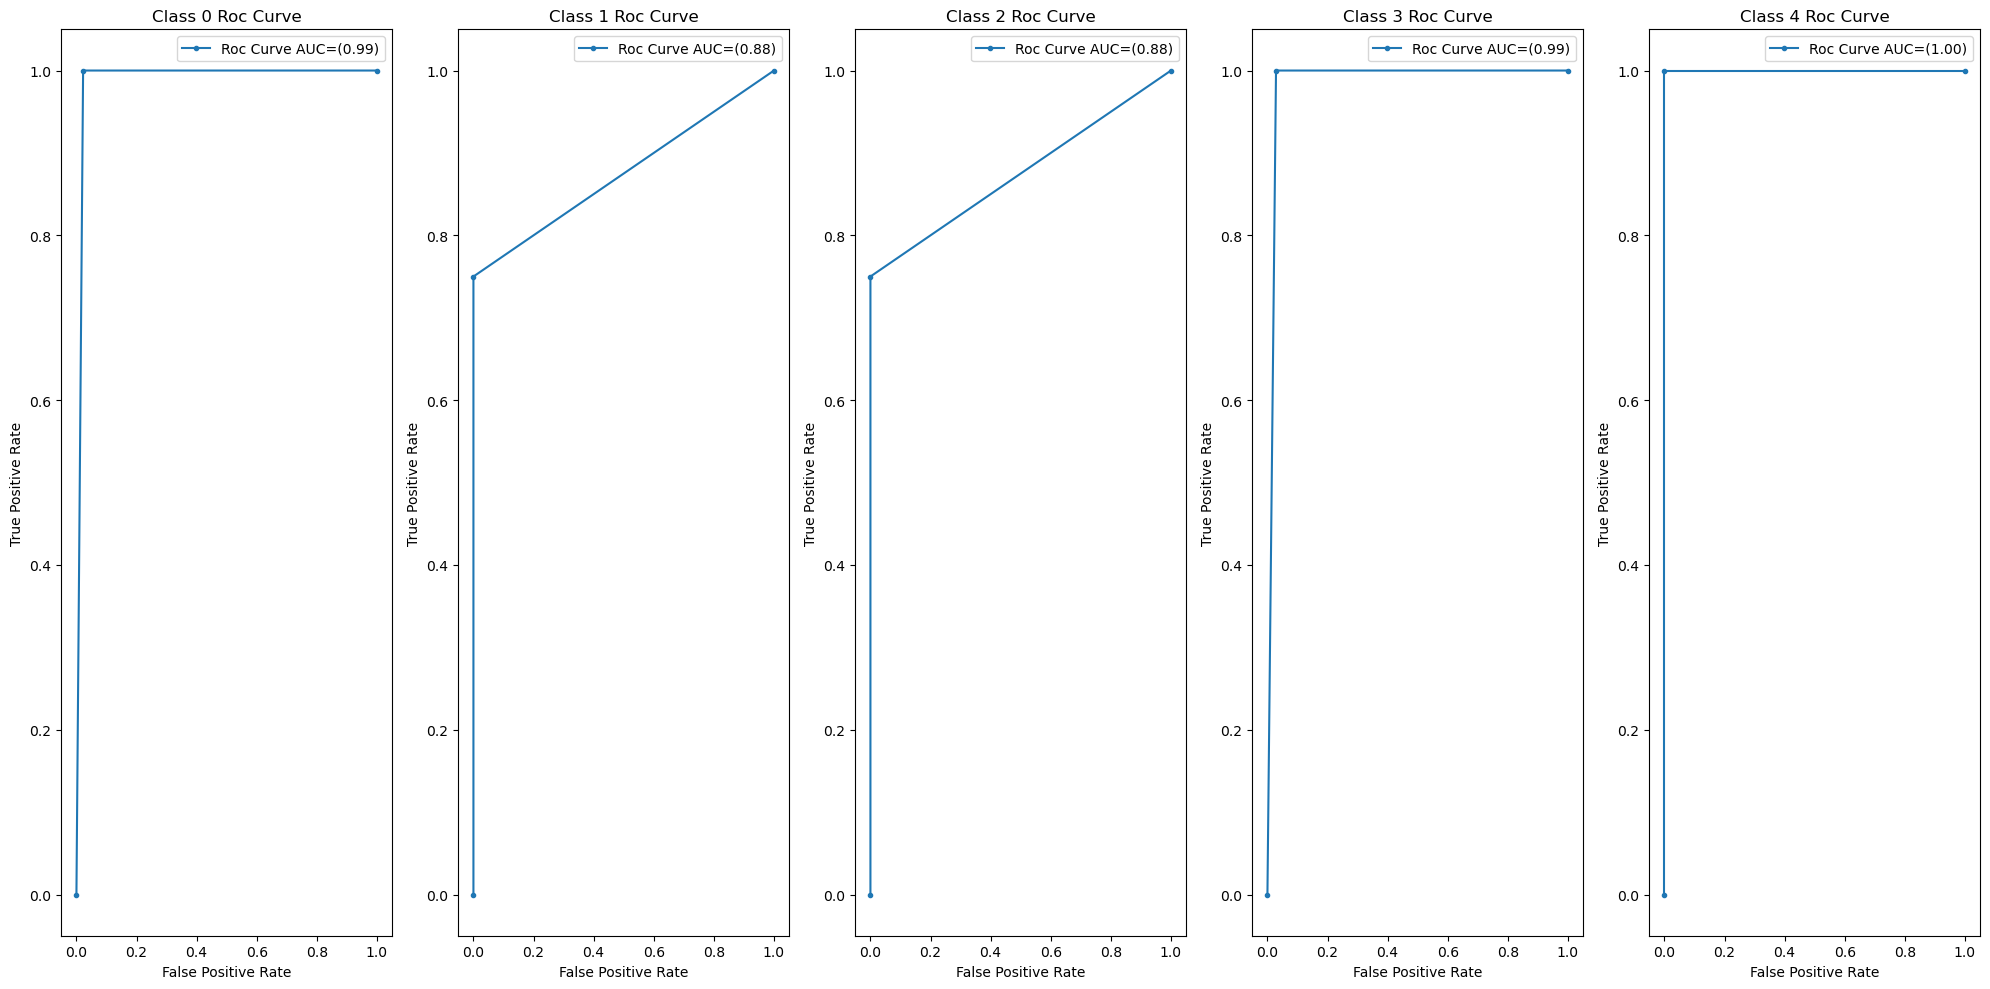

In [52]:
roc_auc(grid3, y_test, X_test_scaled)

In [54]:
df_cclean = pd.read_csv("drug200.csv")
print("Shape: ", df_cclean.shape)
print("Columns: ", df_cclean.columns)
print("İnformations: ")
print(df_cclean.info())
print("İsnull values: ")
print(df_cclean.isnull().sum())
display(df_cclean.head(5))

Shape:  (200, 6)
Columns:  Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None
İsnull values: 
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [61]:
numeric_cols = [i for i in df.columns if df_cclean[i].dtype != "O"]
categoric_cols = [i for i in df.columns if df_cclean[i].dtype == "O"]

In [146]:
class Analysis():
    
    def __init__(self, dataset):
        self.dataset = dataset
        self.cols = dataset.columns
        self.shape = dataset.shape
        self.numeric_cols = [i for i in dataset.columns if dataset[i].dtype != "O"]
        self.categoric_cols = [i for i in dataset.columns if dataset[i].dtype == "O"]
        self.n_cols = len(dataset.columns)
        self.n_numeric = len(self.numeric_cols)
        self.n_categoric = len(self.categoric_cols)

    def explore(self):
        print("Columns: \n", self.cols)
        print("Shape: ", self.shape)
        print("İsnull Values: ") 
        print(self.dataset.isnull().sum())
        print("İnformation: ") 
        self.dataset.info()

    def numeric_dist(self):
        fig, ax = plt.subplots(1, self.n_numeric, figsize=(20,10))
        if self.n_numeric == 1:
            ax = [ax]
        
        for i, col in enumerate(self.numeric_cols):
            sns.kdeplot(
                x=col,
                data = self.dataset,
                ax = ax[i]
            )
            ax[i].set_title(f"{col} distribution")
        
        plt.tight_layout()
        plt.show()

    def numeric_box(self):
        fig, ax = plt.subplots(1, self.n_numeric, figsize=(20,10))
        if self.n_numeric == 1:
            ax = [ax]
        
        for i, col in enumerate(self.numeric_cols):
            sns.boxplot(
                y=col,
                data = self.dataset,
                ax = ax[i]
            )
            ax[i].set_title(f"{col} boxplot")
        
        plt.tight_layout()
        plt.show()

    def correlation(self):
        corr = self.dataset.corr(numeric_only=True)
        plt.figure(figsize=(10,6))
        sns.heatmap(corr, annot=True)
        plt.title("Correlation Heatmap")
        plt.show()

    def categoric_dist(self):
        fig, ax = plt.subplots(1, self.n_categoric, figsize=(20,10))
        if self.n_categoric == 1:
            ax = [ax]

        for i, col in enumerate(self.categoric_cols):
            sns.countplot(
                y=col,
                ax=ax[i],
                data = self.dataset
            )
            ax[i].set_title(f"{col} countplot")
        
        plt.tight_layout()
        plt.show()

    def run_all(self):
        self.explore()
        self.numeric_dist()
        self.numeric_box()
        self.correlation()
        self.categoric_dist()

In [147]:
analiz1 = Analysis(df_cclean)

Columns: 
 Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')
Shape:  (200, 6)
İsnull Values: 
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64
İnformation: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


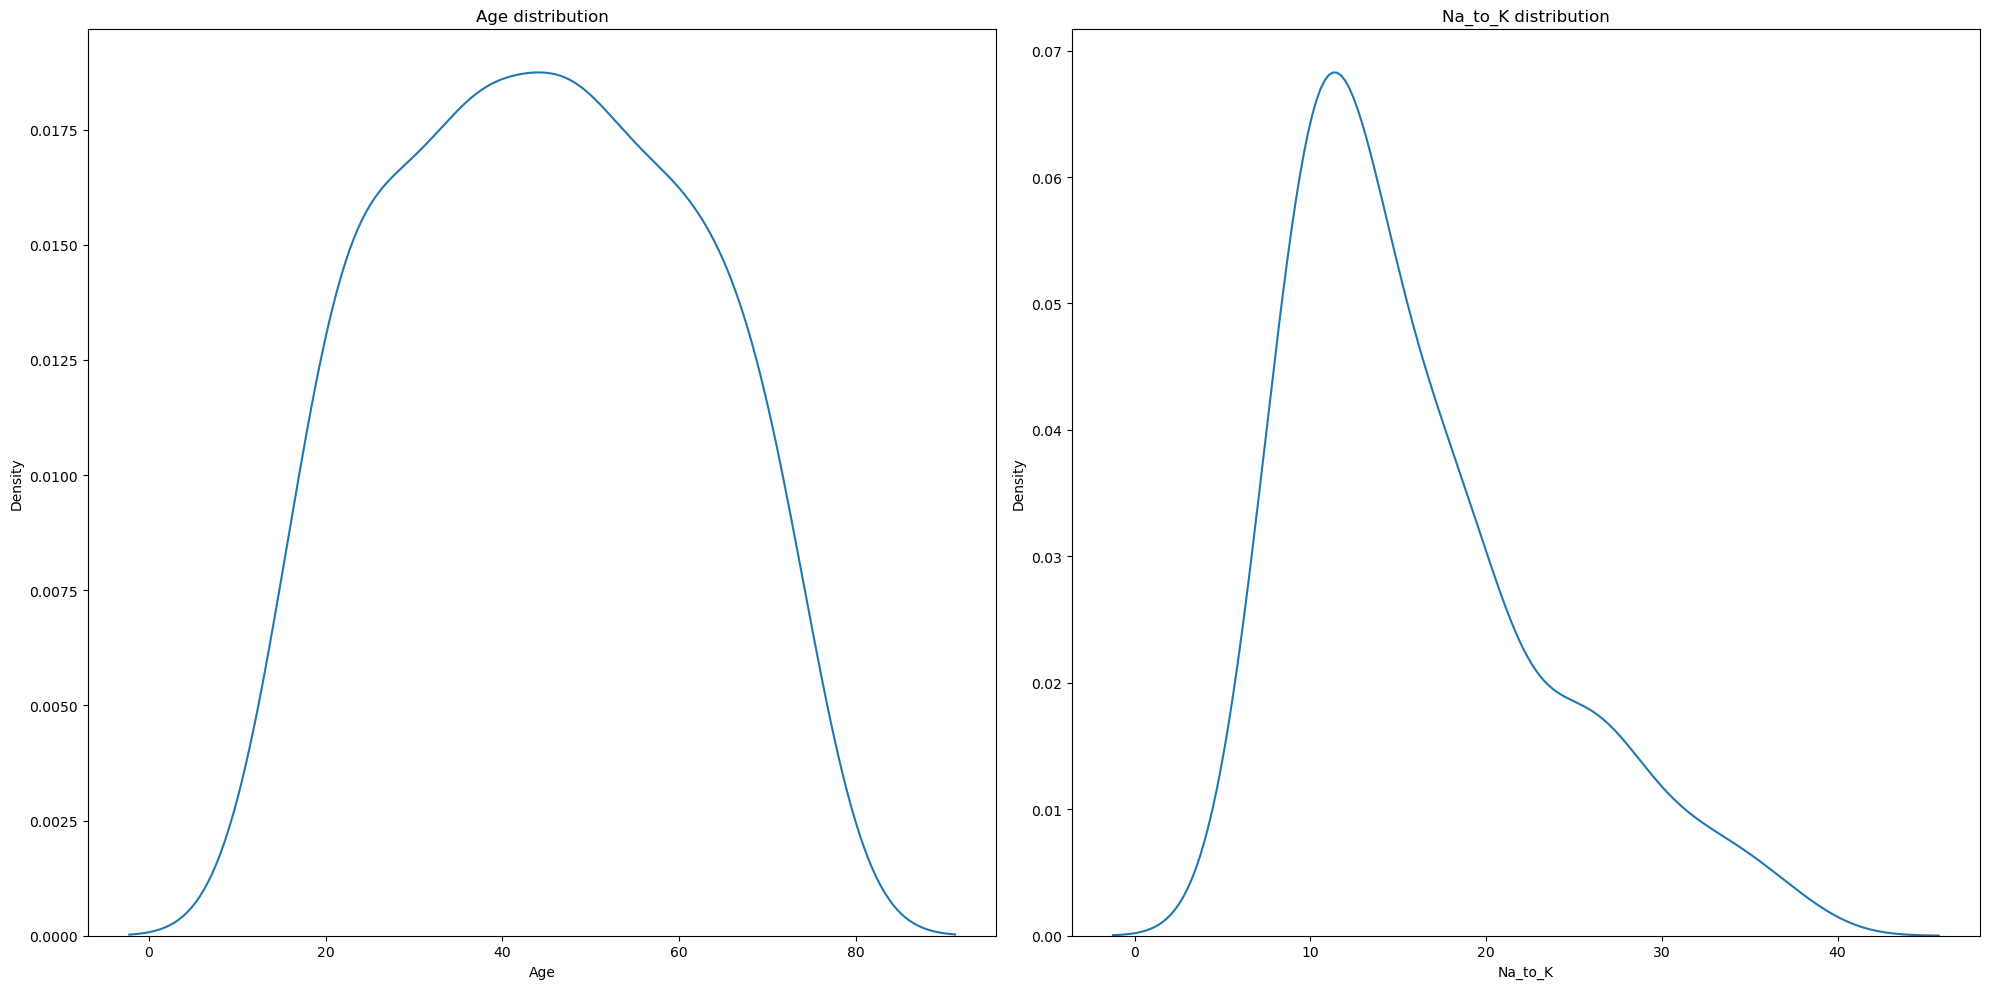

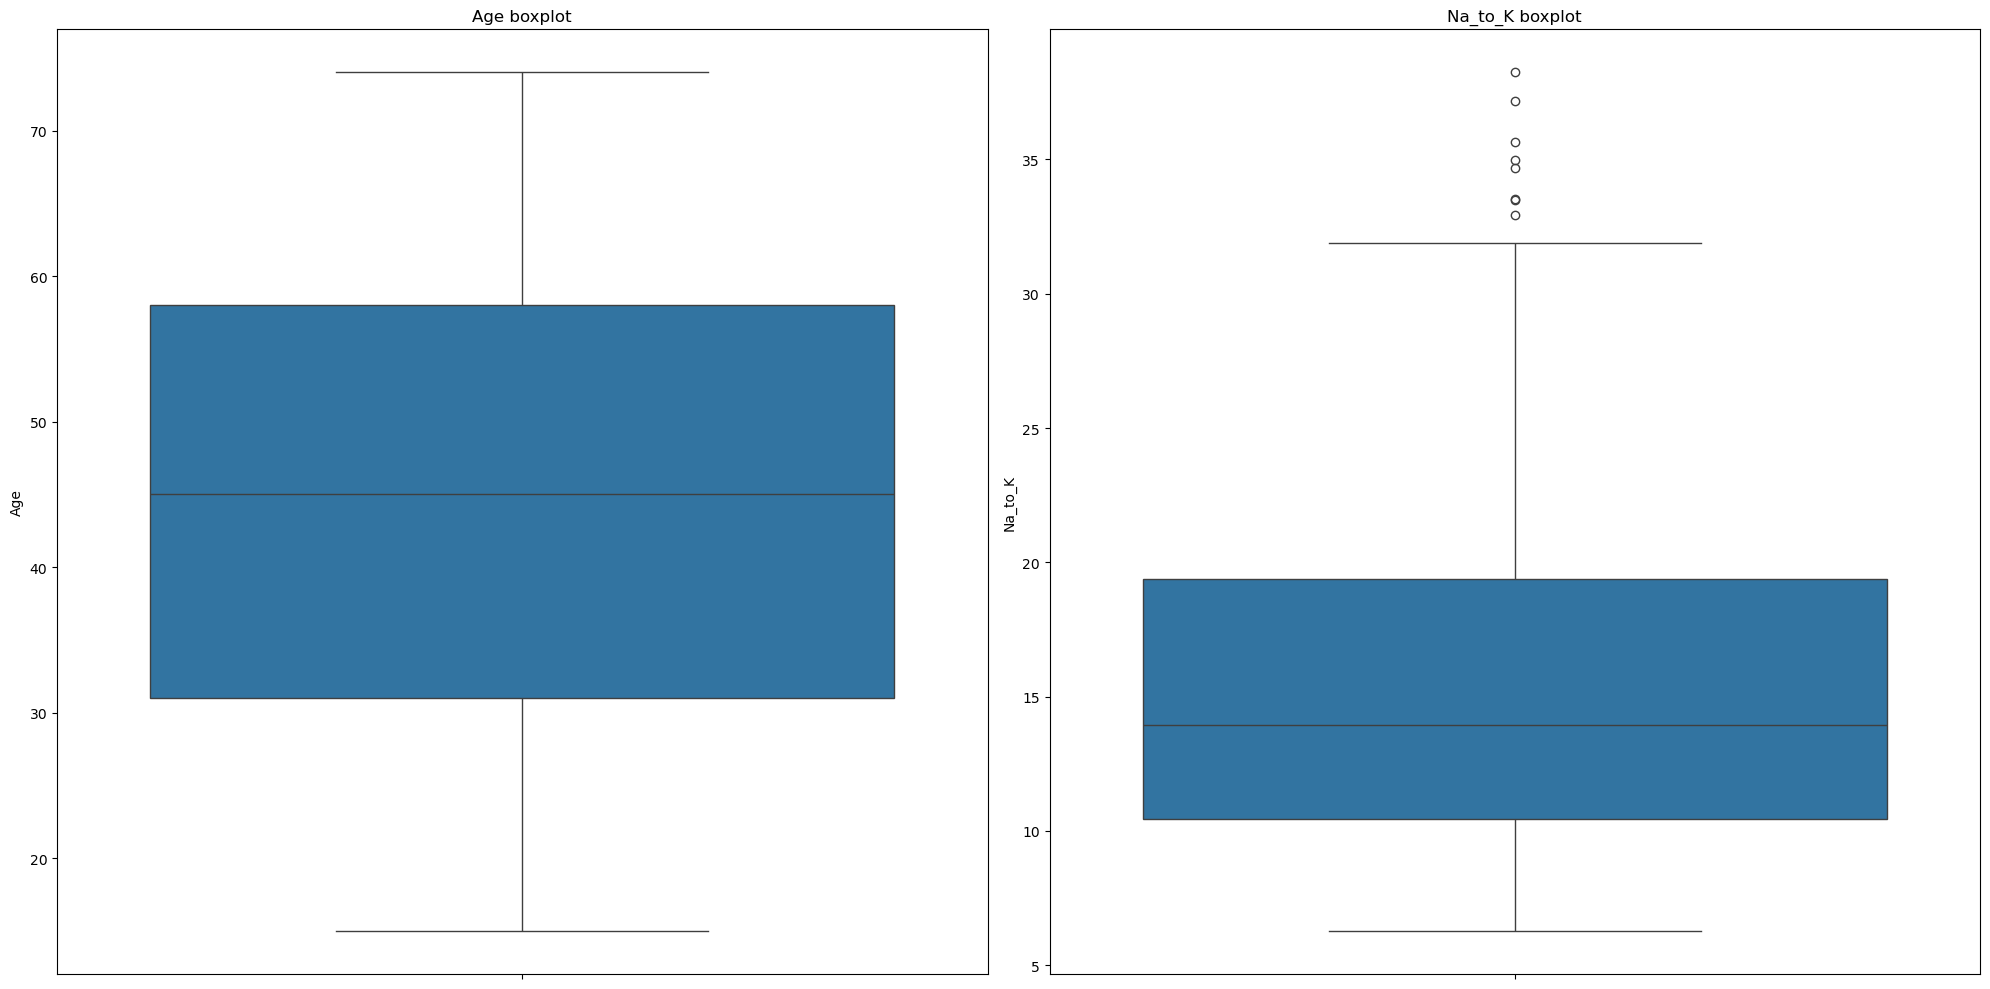

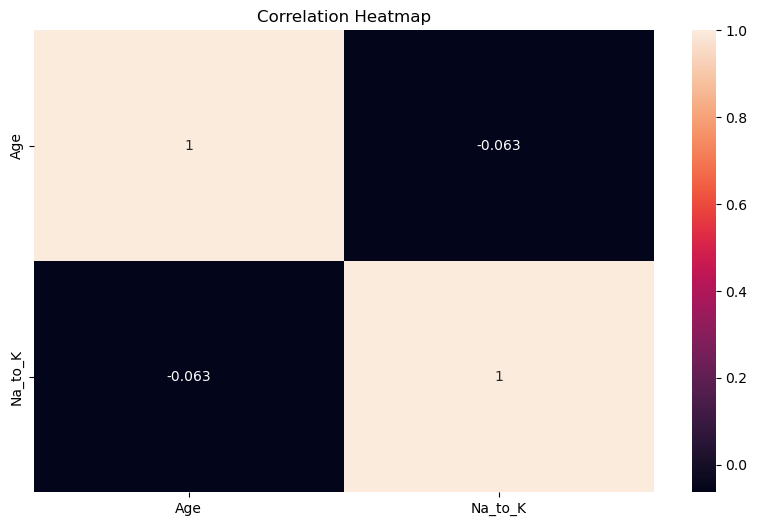

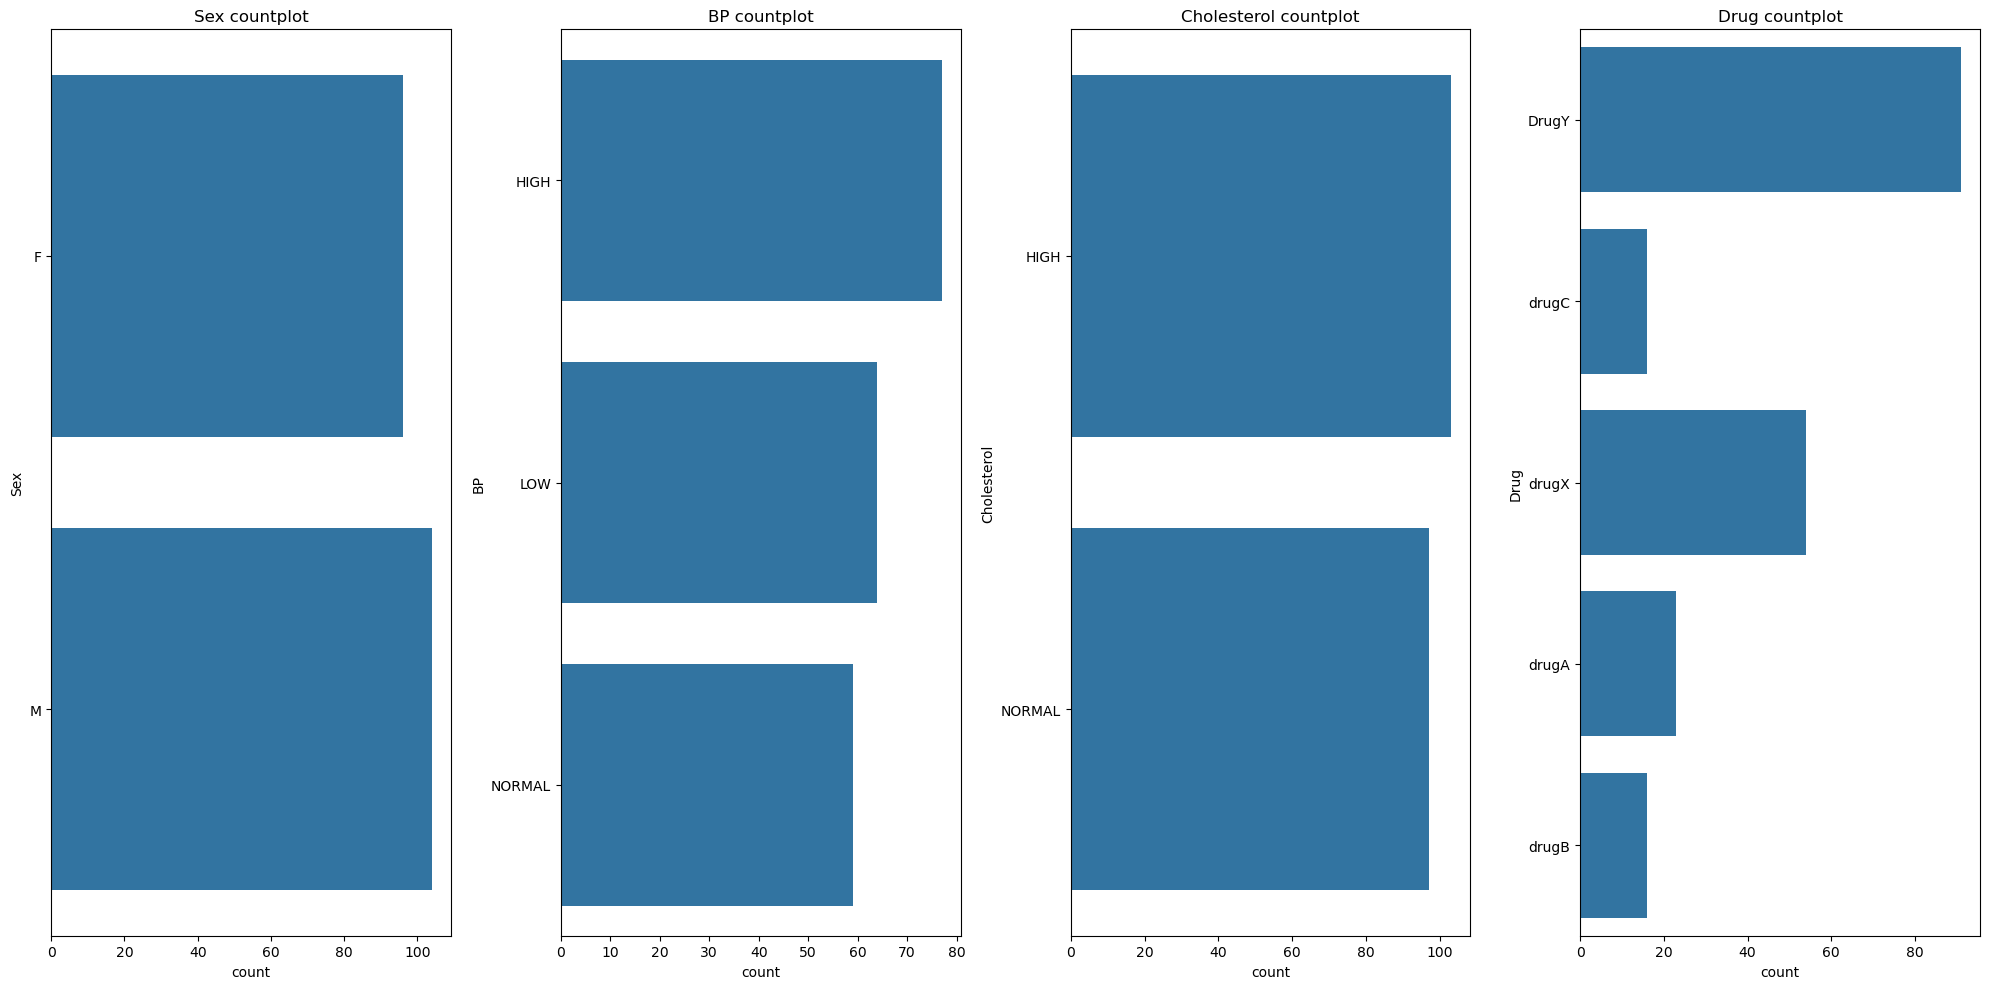

In [148]:
analiz1.run_all()